In [2]:
!pip install -q gdown
import gdown
import os

gdown.download(
    'https://drive.google.com/uc?id=1IJv-oJxpaLcdmkeJMSE1xQBwv9l1mBOE',
    'students.csv', quiet=False
)

!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data

!wget -q -O diabetes.csv https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv

if os.path.exists('diabetes.csv'):
    print("\n Все датасеты успешно загружены!")
else:
    print("\n Ошибка при загрузке diabetes.csv")

Downloading...
From: https://drive.google.com/uc?id=1IJv-oJxpaLcdmkeJMSE1xQBwv9l1mBOE
To: /content/students.csv
100%|██████████| 8.05k/8.05k [00:00<00:00, 17.9MB/s]



 Все датасеты успешно загружены!


# Trees. Random Forest

Rules:

- The homework is graded out of 10 points (+1 bonus point).
- You may use without proof any results covered in the course lectures or seminars, unless deriving those results is explicitly part of a question.
- You may use any open sources, but you must include a reference to them.

**CONSENT**.
<input type="checkbox" disabled checked /> I confirm that I will use AI agents in this home assignment only on the condition that they are documented.

![mem.png](https://github.com/karpovmax/images_python_teaching/blob/main/meme.jpg?raw=true)

## Part 1: Basics of Building a Decision Tree (1.5 points)

In this part all calculations must be implemented as programmed formulas (e.g., using `numpy`). **You may not use ready-made implementations**. For example, if a task asks you to compute entropy, you must implement the formula yourself in some form, but you may not call a ready-made `some_module.entropy()`.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Task 1.1 (0.5 points)** Suppose 10 objects reach a node of a decision tree: 8 have class label $k_1$ and 2 have class label $k_2$. Compute the entropy of this class distribution (using the natural logarithm). Round your answer to two decimals.

In [4]:
p1 = 8 / 10
p2 = 2 / 10
entropy = -(p1 * np.log(p1) + p2 * np.log(p2))
print(f'Entropy = {entropy:.2f}')

Entropy = 0.50


**Task 1.2 (0.5 points)** Suppose further that the node from the previous task is not a leaf, and there exists a split such that all objects of class $k_1$ go to the left subtree and all objects of class $k_2$ go to the right subtree. Compute the information criterion:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

where $R_m$ is the set of objects in the node being split, $j$ is the index of the feature used for the split, $t$ is the split threshold, $R_\ell$ is the set of objects in the left subtree, and $R_r$ is the set of objects in the right subtree.

Now let $H(R)$ be the Gini index:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
where $J$ is the total number of classes (in our case, $J = 2$).

Round your answer to two decimals.

In [5]:
def gini(class_counts):
    total = sum(class_counts)
    if total == 0:
        return 0
    probs = [c / total for c in class_counts]
    return sum(p * (1 - p) for p in probs)

H_parent = gini([8, 2])
H_left = gini([8, 0])
H_right = gini([0, 2])

Q = H_parent - (8/10) * H_left - (2/10) * H_right
print(f'H(parent) = {H_parent:.2f}')
print(f'H(left) = {H_left:.2f}')
print(f'H(right) = {H_right:.2f}')
print(f'Q = {Q:.2f}')

H(parent) = 0.32
H(left) = 0.00
H(right) = 0.00
Q = 0.32


**Task 1.3 (0.5 points)** Suppose a leaf node formed during tree construction contains 10 objects with the following target values (regression task): [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]. What will the model’s predictions be for these objects?

In [6]:
values = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
prediction = np.mean(values)
print(f'Prediction for all objects in this leaf = {prediction}')


Prediction for all objects in this leaf = 40.6


## Part 2: Decision Trees (4.5 points)

In this part we will write and test our own decision tree implementation.

In [7]:
from collections import Counter
from typing import Dict, List, Tuple, Union, Optional

**Task 2.1 (1.5 points)** Implement the function `find_best_split()` that finds the optimal split of a subset of the
training set according to the information gain Q from **Task 1.2**:
Q = H(parent) − w_left * H(left) − w_right * H(right), and we **maximize** Q.

- For **classification**, use **Gini** as the impurity H.
- For **regression**, use the **population variance** of the target as H.
- For **real-valued** features, candidate thresholds are the midpoints between adjacent **distinct** sorted values.
  Do **not** consider thresholds that would send an empty child.
- For **categorical** (integer-encoded) features, use a naive split: for every category value `c`, split by `(x == c)`
  vs `(x != c)` and pick the one that maximizes Q.
- If multiple candidates give the same maximal Q, choose the **smallest threshold** (or smallest category value).

You may use hints from the decision trees seminar.

**Bonus:** An implementation that avoids explicit Python loops over thresholds (i.e., vectorized) earns **+1 bonus point**.


In [8]:
def find_best_split(
    feature_vector, target_vector,
    task="classification", feature_type="real"
):

    feature_vector = np.asarray(feature_vector, dtype=float)
    target_vector = np.asarray(target_vector, dtype=float)
    n = len(feature_vector)

    def impurity(y):
        if len(y) == 0:
            return 0.0
        if task == "classification":
            classes, counts = np.unique(y, return_counts=True)
            p = counts / len(y)
            return np.sum(p * (1 - p))
        else:
            return np.var(y)

    H_parent = impurity(target_vector)

    if feature_type == "real":
        order = np.argsort(feature_vector)
        sorted_feat = feature_vector[order]
        sorted_targ = target_vector[order]

        unique_vals = np.unique(sorted_feat)
        if len(unique_vals) <= 1:
            return np.array([]), np.array([]), None, 0.0

        thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

        gains = np.empty(len(thresholds))
        for i, t in enumerate(thresholds):
            left_mask = sorted_feat <= t
            right_mask = ~left_mask
            n_left = np.sum(left_mask)
            n_right = n - n_left
            if n_left == 0 or n_right == 0:
                gains[i] = 0.0
                continue
            H_left = impurity(sorted_targ[left_mask])
            H_right = impurity(sorted_targ[right_mask])
            gains[i] = H_parent - (n_left / n) * H_left - (n_right / n) * H_right

        if len(gains) == 0 or np.max(gains) <= 0:
            return thresholds, gains, None, 0.0

        best_idx = np.argmax(gains)
        return thresholds, gains, thresholds[best_idx], gains[best_idx]

    elif feature_type == "categorical":
        categories = np.unique(feature_vector)
        if len(categories) <= 1:
            return np.array([]), np.array([]), None, 0.0

        gains = np.empty(len(categories))
        for i, c in enumerate(categories):
            left_mask = feature_vector == c
            right_mask = ~left_mask
            n_left = np.sum(left_mask)
            n_right = n - n_left
            if n_left == 0 or n_right == 0:
                gains[i] = 0.0
                continue
            H_left = impurity(target_vector[left_mask])
            H_right = impurity(target_vector[right_mask])
            gains[i] = H_parent - (n_left / n) * H_left - (n_right / n) * H_right

        if np.max(gains) <= 0:
            return categories, gains, None, 0.0

        best_idx = np.argmax(gains)
        return categories, gains, categories[best_idx], gains[best_idx]


You can test this function on the **California Housing** dataset from `sklearn`

In [9]:
from sklearn.datasets import fetch_california_housing
cal = fetch_california_housing(as_frame=True)
X = cal.frame.drop(columns=['MedHouseVal'])
y = cal.frame['MedHouseVal']
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
thresholds, variances, threshold_best, variance_best = find_best_split(
    X["MedInc"].to_numpy(),
    y,
    task="regression",
    feature_type="real"
)

Plot the dependence of the error criterion value on the threshold when splitting a node by the `MedInc` feature.

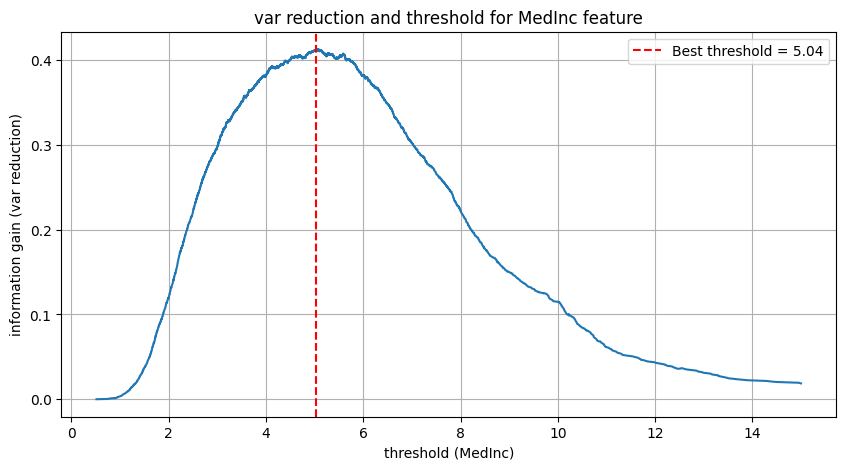

best threshold: 5.0351, best gain: 0.412751


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, variances)
plt.axvline(threshold_best, color='r', linestyle='--', label=f'Best threshold = {threshold_best:.2f}')
plt.xlabel('threshold (MedInc)')
plt.ylabel('information gain (var reduction)')
plt.title('var reduction and threshold for MedInc feature')
plt.legend()
plt.grid(True)
plt.show()
print(f'best threshold: {threshold_best:.4f}, best gain: {variance_best:.6f}')


**Task 2.2 (1 point)** Study the provided decision tree code, fill in the missing parts, and implement `_predict_node()`.

Tree construction follows the basic greedy algorithm.
- **Best split selection:** choose the split that maximizes information gain Q using Gini as the impurity for classification.
- **Stopping criteria:** all objects in a node share the same class, or no feature allows a valid split (respecting any min-samples settings), or the maximum depth is reached (if specified).
- **Leaf prediction:** the most frequent class in the leaf.


In [13]:
class DecisionTree:

    def __init__(
        self,
        feature_types,
        max_depth=None,
        min_samples_split=None,
        min_samples_leaf=None,
        task="classification"
    ):
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        self._tree = {}
        self._feature_types = feature_types
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

    def _fit_node(self, sub_X, sub_y, node, depth=0):

        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        if self._max_depth is not None and depth >= self._max_depth:
            node["type"] = "terminal"
            if self.task == "classification":
                node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
                node["class"] = np.mean(sub_y)
            return

        if self._min_samples_split is not None and len(sub_y) < self._min_samples_split:
            node["type"] = "terminal"
            if self.task == "classification":
                node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
                node["class"] = np.mean(sub_y)
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                feature_vector = sub_X[:, feature]

            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if threshold is None:
                continue

            if gini_best is None or gini > gini_best:
                feature_best = feature
                gini_best = gini

                if feature_type == "real":
                    threshold_best = threshold
                    split = sub_X[:, feature] <= threshold
                elif feature_type == "categorical":
                    threshold_best = threshold
                    split = sub_X[:, feature] == threshold
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            if self.task == "classification":
                node["class"] = Counter(sub_y).most_common(1)[0][0]
            else:
                node["class"] = np.mean(sub_y)
            return

        if self._min_samples_leaf is not None:
            if np.sum(split) < self._min_samples_leaf or np.sum(~split) < self._min_samples_leaf:
                node["type"] = "terminal"
                if self.task == "classification":
                    node["class"] = Counter(sub_y).most_common(1)[0][0]
                else:
                    node["class"] = np.mean(sub_y)
                return

        node["type"] = "nonterminal"
        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"], depth + 1)
        self._fit_node(sub_X[~split], sub_y[~split], node["right_child"], depth + 1)

    def _predict_node(self, x, node):
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        if "threshold" in node:
            if x[feature] <= node["threshold"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])
        elif "category_split" in node:
            if x[feature] == node["category_split"]:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)


**Task 2.3 (1 point)** Load the [students.csv](https://drive.google.com/file/d/1IJv-oJxpaLcdmkeJMSE1xQBwv9l1mBOE/view?usp=sharing) table (a slightly modified
[User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling) dataset).
The object features are in the first five columns, and the target variable (class: 0 or 1) is in the last column.

On a single figure, plot five “threshold (or category) - information gain (Gini)” curves:
- For real-valued features: scan thresholds as in Task 2.1 and plot a smooth curve of Q vs threshold.
- For categorical features (integer-encoded): try each category split `(x == c)` vs `(x != c)` and plot Q as stem markers against category values.

Separately, visualize scatter plots of “feature value — class” for all five features.

Then answer:
- Based on the gain curves, which feature would you split on first?
- Does this agree with the visual assessment of the scatter plots?
- How do “good” features (near-perfect separators) look in the gain curves vs “poor” features?


Feature types: {'STG': 'real', 'SCG': 'real', 'STR': 'real', 'LPR': 'real', 'PEG': 'real'}


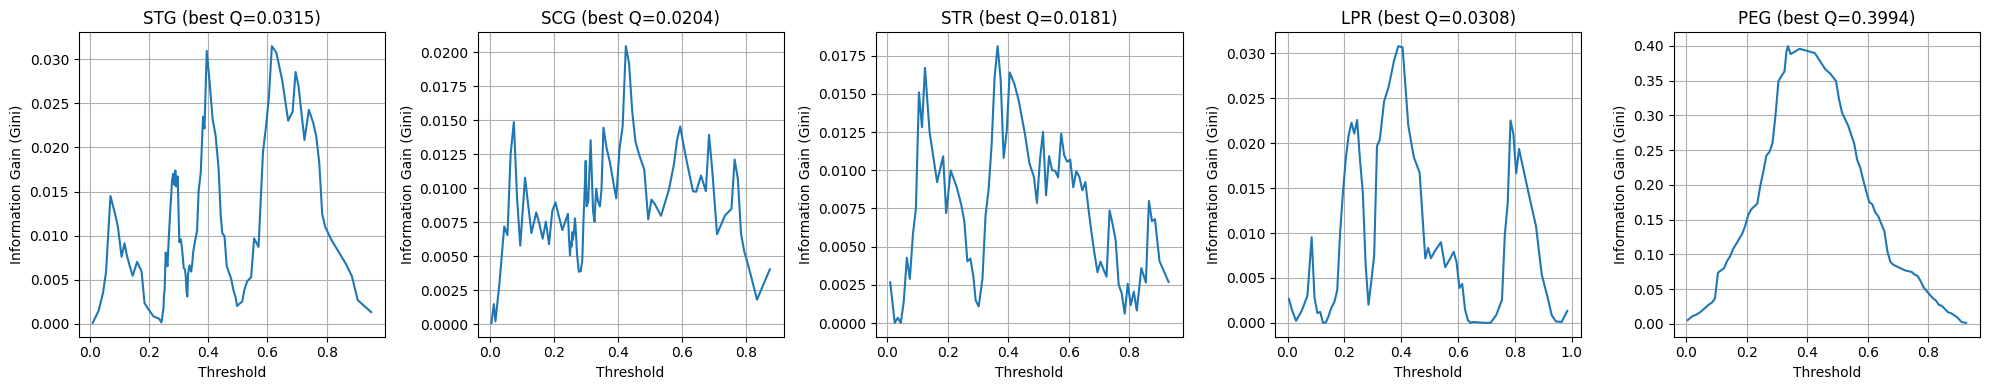

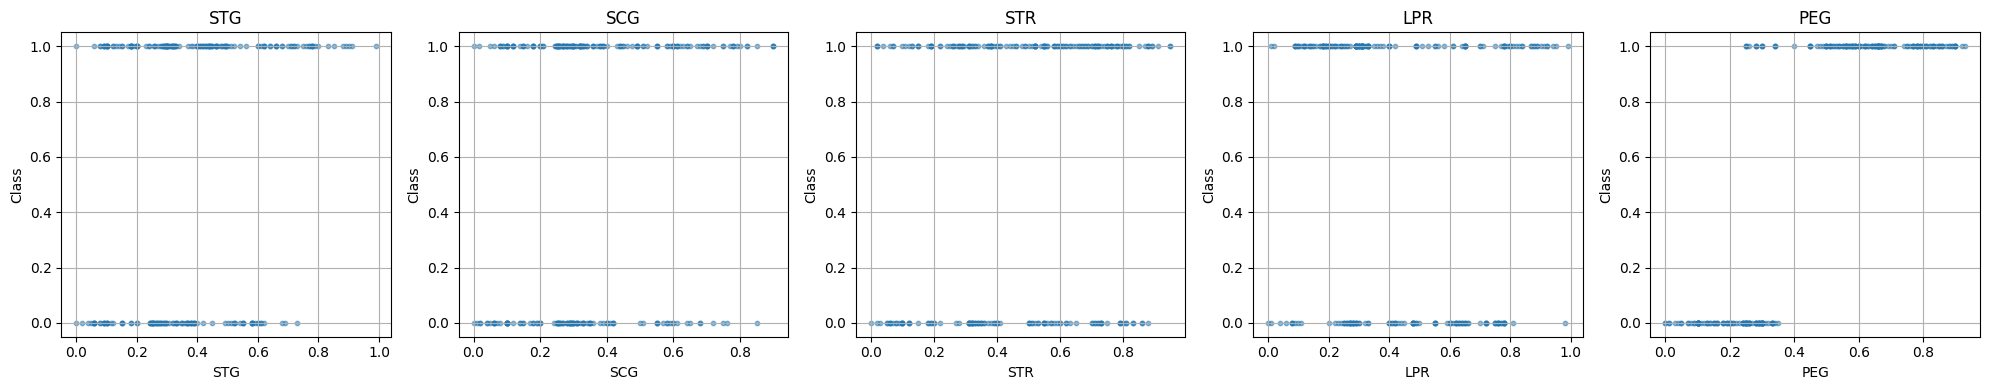


Best gains per feature:
  PEG: 0.3994
  STG: 0.0315
  LPR: 0.0308
  SCG: 0.0204
  STR: 0.0181

first split should be on: PEG
features with high gain show clear separation in scatter plots (classes are well-separated).
features with low gain show overlapping classes in scatter plots.


In [14]:
students = pd.read_csv('students.csv')
feature_cols = ['STG', 'SCG', 'STR', 'LPR', 'PEG']
target_col = 'UNS'
y_st = students[target_col].values

feature_types_st = []
for col in feature_cols:
    if students[col].dtype in ['int64', 'int32'] and students[col].nunique() < 20:
        feature_types_st.append('categorical')
    else:
        feature_types_st.append('real')
print('Feature types:', dict(zip(feature_cols, feature_types_st)))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, col in enumerate(feature_cols):
    ftype = feature_types_st[idx]
    thrs, gains, best_t, best_g = find_best_split(students[col].values, y_st, 'classification', ftype)
    ax = axes[idx]
    if ftype == 'real':
        ax.plot(thrs, gains)
    else:
        ax.stem(thrs, gains)
    ax.set_title(f'{col} (best Q={best_g:.4f})')
    ax.set_xlabel('Threshold' if ftype == 'real' else 'Category')
    ax.set_ylabel('Information Gain (Gini)')
    ax.grid(True)
plt.tight_layout()
plt.savefig('gain_curves.png', dpi=100)
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    ax.scatter(students[col], y_st, alpha=0.5, s=10)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Class')
    ax.grid(True)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=100)
plt.show()

best_gains = {}
for idx, col in enumerate(feature_cols):
    _, _, _, best_g = find_best_split(students[col].values, y_st, 'classification', feature_types_st[idx])
    best_gains[col] = best_g
print('\nBest gains per feature:')
for k, v in sorted(best_gains.items(), key=lambda x: -x[1]):
    print(f'  {k}: {v:.4f}')
best_feature = max(best_gains, key=best_gains.get)
print(f'\nfirst split should be on: {best_feature}')
print('features with high gain show clear separation in scatter plots (classes are well-separated).')
print('features with low gain show overlapping classes in scatter plots.')


In [15]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


**Task 2.4 (1 point)** Test your decision tree on the
[mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) dataset.

1. Download `agaricus-lepiota.data`.
2. Read the table using `pandas`.
3. Apply `LabelEncoder` (from `sklearn`) to each column to transform string categories into integers.

The first column is the target (e — edible, p — poisonous). Measure quality using accuracy (it doesn't matter which class is 1).
Split the data 50/50 into train/test using a fixed `random_state` and stratification.
Train your decision tree (treat all features as categorical in your implementation) and compute accuracy on the test set.


In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

mushroom = pd.read_csv('agaricus-lepiota.data', header=None)
print(f'Mushroom dataset shape: {mushroom.shape}')

le_dict = {}
for col in mushroom.columns:
    le = LabelEncoder()
    mushroom[col] = le.fit_transform(mushroom[col].astype(str))
    le_dict[col] = le

y_mush = mushroom[0].values
X_mush = mushroom.drop(columns=[0]).values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mush, y_mush, test_size=0.5, random_state=42, stratify=y_mush
)

feature_types_mush = ['categorical'] * X_mush.shape[1]

dt_mush = DecisionTree(feature_types=feature_types_mush, task='classification')
dt_mush.fit(X_train_m, y_train_m)
y_pred_m = dt_mush.predict(X_test_m)
acc_mush = accuracy_score(y_test_m, y_pred_m)
print(f'Accuracy on test set: {acc_mush:.4f}')


Mushroom dataset shape: (8124, 23)
Accuracy on test set: 1.0000


## Part 3: Bagging and Random Forest (4 points)

In this part we will work with the [patient diabetes prediction task](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). We will examine bagging over decision trees and random forests and compare their performance.

In [17]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [18]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Let’s look at the target variable distribution

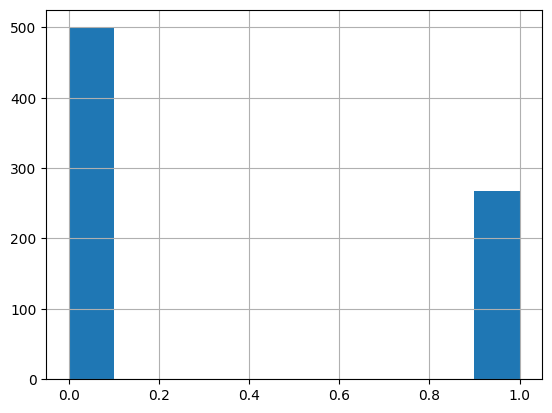

In [19]:
data['Outcome'].hist()
plt.show()

**Task 3.1 (0.5 points)** Split the data into features and target. Split the dataset into **training** and **test**
parts in a 7:3 ratio using a fixed `random_state` and **stratify=y**. Then split the training set into
training–training and training–validation in a 7:3 ratio (also stratified). You should end up with three sets:
training–training (0.49 of the original dataset), training–validation (0.21), and test (0.30).


In [21]:
data = pd.read_csv('diabetes.csv')
X_d = data.drop(columns=['Outcome'])
y_d = data['Outcome']

X_train_full, X_test_d, y_train_full, y_test_d = train_test_split(
    X_d, y_d, test_size=0.3, random_state=42, stratify=y_d
)

X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(
    X_train_full, y_train_full, test_size=0.3, random_state=42, stratify=y_train_full
)

print(f'train-train: {X_train_train.shape[0]} ({X_train_train.shape[0]/len(data):.2f})')
print(f'train-val: {X_train_val.shape[0]} ({X_train_val.shape[0]/len(data):.2f})')
print(f'test: {X_test_d.shape[0]} ({X_test_d.shape[0]/len(data):.2f})')


train-train: 375 (0.49)
train-val: 162 (0.21)
test: 231 (0.30)


**Task 3.2 (1 point)** On the training–validation set, tune `max_depth` and `min_samples_leaf` for `DecisionTreeClassifier`. To do this:
1. Create lists of possible values to search over.
2. For each pair, train a tree on the training–training set and evaluate quality on the training–validation set. Use the `F1-score` as the criterion.
3. Choose the pair that gives the highest `F1-score` on the training–validation set.

Train a decision tree with the selected hyperparameters on the **full training** set. Evaluate classification quality on the test set using the metrics `accuracy`, `precision`, `recall`, and `ROC AUC`.

In [26]:
from sklearn.metrics import f1_score

max_depths = [3, 5, 7, 10, 15, 20, None]
min_samples_leafs = [1, 2, 5, 10, 20, 50]

best_f1 = 0
best_params_dt = {}
for md in max_depths:
    for msl in min_samples_leafs:
        clf = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        clf.fit(X_train_train, y_train_train)
        y_pred_val = clf.predict(X_train_val)
        f1 = f1_score(y_train_val, y_pred_val)
        if f1 > best_f1:
            best_f1 = f1
            best_params_dt = {'max_depth': md, 'min_samples_leaf': msl}

print(f'best params: {best_params_dt}, F1 on val: {best_f1:.4f}')

dt_best = DecisionTreeClassifier(**best_params_dt, random_state=42)
dt_best.fit(X_train_full, y_train_full)
y_pred_test_dt = dt_best.predict(X_test_d)
y_proba_test_dt = dt_best.predict_proba(X_test_d)[:, 1]

print(f'\ndecision tree on test set:')
print(f'accuracy: {accuracy_score(y_test_d, y_pred_test_dt):.4f}')
print(f'precision: {precision_score(y_test_d, y_pred_test_dt):.4f}')
print(f'recall: {recall_score(y_test_d, y_pred_test_dt):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_test_dt):.4f}')


best params: {'max_depth': 5, 'min_samples_leaf': 20}, F1 on val: 0.6250

decision tree on test set:
accuracy: 0.7273
precision: 0.6452
recall: 0.4938
ROC AUC: 0.7951


**Task 3.3 (0.5 points)** Train a [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) with 50 trees on the **full training** set. Evaluate classification quality on the test set using the same metrics.

In [27]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50, random_state=42
)
bag_clf.fit(X_train_full, y_train_full)
y_pred_bag = bag_clf.predict(X_test_d)
y_proba_bag = bag_clf.predict_proba(X_test_d)[:, 1]

print('bagging on test set:')
print(f'accuracy: {accuracy_score(y_test_d, y_pred_bag):.4f}')
print(f'precision: {precision_score(y_test_d, y_pred_bag):.4f}')
print(f'recall: {recall_score(y_test_d, y_pred_bag):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_bag):.4f}')


bagging on test set:
accuracy: 0.7532
precision: 0.6875
recall: 0.5432
ROC AUC: 0.8269


**Task 3.4 (1 point)** Perform cross-validation on the full training set and tune `max_depth` and `min_samples_split` for a `Random Forest` with 50 trees. To do this:

1. Create lists of possible values to search over.
2. For each pair, perform cross-validation on the full training set. Choose the number of folds at your discretion. Use the `F1-score` as the criterion. Average the criterion over all cross-validation runs.
3. Choose the pair that gives the best average quality.

Train a random forest with the selected hyperparameters on the **full training** set. Evaluate classification quality using the same metrics. Which of the three models performed best?

In [29]:
from sklearn.model_selection import cross_val_score

max_depths_rf = [3, 5, 7, 10, 15, None]
min_samples_splits_rf = [2, 5, 10, 20]

best_f1_rf = 0
best_params_rf = {}
for md in max_depths_rf:
    for mss in min_samples_splits_rf:
        rf = RandomForestClassifier(n_estimators=50, max_depth=md, min_samples_split=mss, random_state=42)
        scores = cross_val_score(rf, X_train_full, y_train_full, cv=5, scoring='f1')
        mean_f1 = scores.mean()
        if mean_f1 > best_f1_rf:
            best_f1_rf = mean_f1
            best_params_rf = {'max_depth': md, 'min_samples_split': mss}

print(f'best RF params: {best_params_rf}, CV F1: {best_f1_rf:.4f}')

rf_best = RandomForestClassifier(n_estimators=50, **best_params_rf, random_state=42)
rf_best.fit(X_train_full, y_train_full)
y_pred_rf = rf_best.predict(X_test_d)
y_proba_rf = rf_best.predict_proba(X_test_d)[:, 1]

print(f'\nrandom forest on test set:')
print(f'accuracy: {accuracy_score(y_test_d, y_pred_rf):.4f}')
print(f'precision: {precision_score(y_test_d, y_pred_rf):.4f}')
print(f'recall: {recall_score(y_test_d, y_pred_rf):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test_d, y_proba_rf):.4f}')

print('\ncomparison')
print(f'decision tree ROC AUC: {roc_auc_score(y_test_d, y_proba_test_dt):.4f}')
print(f'bagging ROC AUC: {roc_auc_score(y_test_d, y_proba_bag):.4f}')
print(f'random forest ROC AUC: {roc_auc_score(y_test_d, y_proba_rf):.4f}')


best RF params: {'max_depth': None, 'min_samples_split': 10}, CV F1: 0.6334

random forest on test set:
accuracy: 0.7403
precision: 0.6567
recall: 0.5432
ROC AUC: 0.8207

comparison
decision tree ROC AUC: 0.7951
bagging ROC AUC: 0.8269
random forest ROC AUC: 0.8207


**Task 3.5 (0.5 points)** Plot the dependence of ROC AUC on the test set versus the number of trees (`n_estimators`) for a random forest trained on the **full training** set. What conclusions can be drawn?

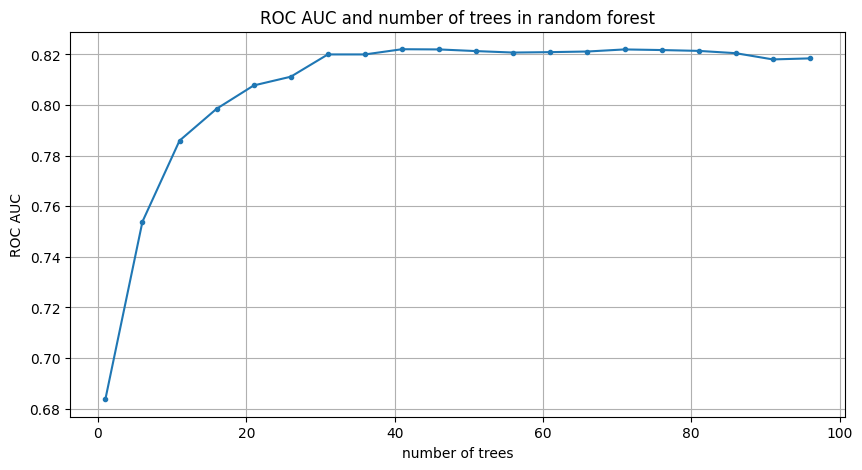

conclusion: ROC AUC grows rapidly at first and then plateaus.
adding more trees beyond a certain point yields diminishing returns.


In [31]:
n_estimators_range = list(range(1, 101, 5))
roc_aucs = []
for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n_est, **best_params_rf, random_state=42)
    rf_temp.fit(X_train_full, y_train_full)
    y_proba_temp = rf_temp.predict_proba(X_test_d)[:, 1]
    roc_aucs.append(roc_auc_score(y_test_d, y_proba_temp))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, roc_aucs, marker='o', markersize=3)
plt.xlabel('number of trees')
plt.ylabel('ROC AUC')
plt.title('ROC AUC and number of trees in random forest')
plt.grid(True)
plt.show()

print('conclusion: ROC AUC grows rapidly at first and then plateaus.')
print('adding more trees beyond a certain point yields diminishing returns.')


**Task 3.6 (0.5 points)** For the best random forest model from **Task 3.4**, compute feature importances and build a bar plot. Which feature turned out to be the most important for determining diabetes?

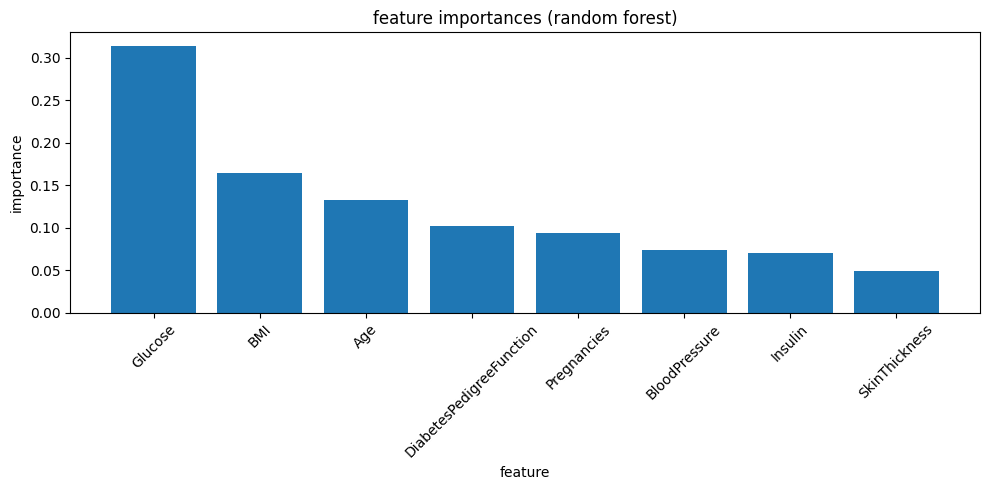

most important feature: Glucose  (importance = 0.3142)


In [32]:
importances = rf_best.feature_importances_
feature_names = X_d.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45)
plt.xlabel('feature')
plt.ylabel('importance')
plt.title('feature importances (random forest)')
plt.tight_layout()
plt.show()

print(f'most important feature: {feature_names[sorted_idx[0]]}  '
      f'(importance = {importances[sorted_idx[0]]:.4f})')


---

**When using AI, chatbots, generative and large language models** (ChatGPT, DeepSeek, Qwen, Mistral/Mixtral, Microsoft Copilot, Gemini, Claude, Grok, YandexGPT, GigaChat and others), **you must specify the following for each of them in LLM Documentation in the next cell**:
- The full name and version of the model, as well as a link to the service used
   * The application or browser version with built-in assistant, TG bot, etc.
- **All** used prompts
- Tell us how you rate the AI's work, and what specific problem did it help solve?
- The verdict on recognizing the decision as written by AI without observing these rules is made by a teaching team.
   * Such cases are to be considered as plagiarism.


<font color=green><h4><b>LLM Documentation if used</b></h4></font>
<font color=red><b>Your answer here.</b></font>

I used Claude Opus 4.6 to help me with downloading files in the first code cell.
